In [ ]:
# MODEL 1: EfficientNetB2 (recommended for leaf-disease texture)
# ============================================================

!pip -q install scikit-learn

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB2
from tensorflow.keras.applications.efficientnet import preprocess_input
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize

In [ ]:
# ✅ CHANGE ONLY THESE
TRAIN_DIR = "/content/drive/MyDrive/Capstone Dataset/Guava_Fruit_Dieases/Train"
TEST_DIR  = "/content/drive/MyDrive/Capstone Dataset/Guava_Fruit_Dieases/Test"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
EPOCHS_HEAD = 5
EPOCHS_FINETUNE = 25
LR_HEAD = 1e-3
LR_FINETUNE = 1e-5

In [ ]:
# 4) Load Dataset (Already split: Train/Test)
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, seed=SEED, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode="int", shuffle=True
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR, seed=SEED, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode="int", shuffle=False
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR, seed=SEED, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode="int", shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", class_names)

if val_ds.class_names != class_names:
    raise ValueError(
        "Class mismatch between Train and Test folders.\n"
        f"Train: {class_names}\nTest : {val_ds.class_names}"
    )

Found 3520 files belonging to 4 classes.
Found 880 files belonging to 4 classes.
Found 880 files belonging to 4 classes.
Classes: ['Anthracnose', 'Healthy', 'Scab', 'Styler end root']


In [ ]:
# 5) Data Pipeline Optimization
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000, seed=SEED).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)

In [ ]:
# 6) Data Augmentation
data_aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.1),
])

In [ ]:
# 7) Build Pretrained Model (Base + Custom Head)
base = EfficientNetB2(include_top=False, weights="imagenet", input_shape=IMG_SIZE + (3,))
base.trainable = False

inputs = layers.Input(shape=IMG_SIZE + (3,))
x = data_aug(inputs)
x = preprocess_input(x)
x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.30)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)
model = models.Model(inputs, outputs)

31790344/31790344 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# 8) Train Head (Frozen base)
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", patience=2, factor=0.5),
]

model.compile(
    optimizer=tf.keras.optimizers.Adam(LR_HEAD),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
h1 = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_HEAD, callbacks=callbacks)

Epoch 1/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 752s 2s/step - accuracy: 0.4944 - loss: 1.1651 - val_accuracy: 0.6375 - val_loss: 0.9671 - learning_rate: 0.0010
Epoch 2/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 14s 130ms/step - accuracy: 0.6850 - loss: 0.8000 - val_accuracy: 0.6557 - val_loss: 0.9276 - learning_rate: 0.0010
Epoch 3/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 15s 133ms/step - accuracy: 0.7378 - loss: 0.6944 - val_accuracy: 0.6136 - val_loss: 1.0109 - learning_rate: 0.0010
Epoch 4/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 15s 136ms/step - accuracy: 0.7495 - loss: 0.6589 - val_accuracy: 0.6102 - val_loss: 1.0072 - learning_rate: 0.0010
Epoch 5/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 15s 140ms/step - accuracy: 0.7573 - loss: 0.6420 - val_accuracy: 0.6307 - val_loss: 1.0092 - learning_rate: 5.0000e-04


In [ ]:
# 9) Fine-tuning (Unfreeze last layers)
base.trainable = True
for layer in base.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(LR_FINETUNE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
h2 = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_FINETUNE, callbacks=callbacks)

Epoch 1/25
110/110 ━━━━━━━━━━━━━━━━━━━━ 39s 199ms/step - accuracy: 0.6075 - loss: 0.9438 - val_accuracy: 0.6193 - val_loss: 1.0371 - learning_rate: 1.0000e-05
Epoch 2/25
110/110 ━━━━━━━━━━━━━━━━━━━━ 19s 170ms/step - accuracy: 0.6969 - loss: 0.7792 - val_accuracy: 0.6114 - val_loss: 1.0940 - learning_rate: 1.0000e-05
Epoch 3/25
110/110 ━━━━━━━━━━━━━━━━━━━━ 19s 169ms/step - accuracy: 0.7318 - loss: 0.7046 - val_accuracy: 0.5920 - val_loss: 1.1259 - learning_rate: 1.0000e-05
Epoch 4/25
110/110 ━━━━━━━━━━━━━━━━━━━━ 18s 163ms/step - accuracy: 0.7767 - loss: 0.6227 - val_accuracy: 0.5943 - val_loss: 1.1398 - learning_rate: 5.0000e-06
Epoch 5/25
110/110 ━━━━━━━━━━━━━━━━━━━━ 18s 164ms/step - accuracy: 0.7806 - loss: 0.6009 - val_accuracy: 0.5932 - val_loss: 1.1502 - learning_rate: 5.0000e-06
Epoch 6/25
110/110 ━━━━━━━━━━━━━━━━━━━━ 18s 166ms/step - accuracy: 0.7935 - loss: 0.5751 - val_accuracy: 0.5795 - val_loss: 1.1613 - learning_rate: 2.5000e-06


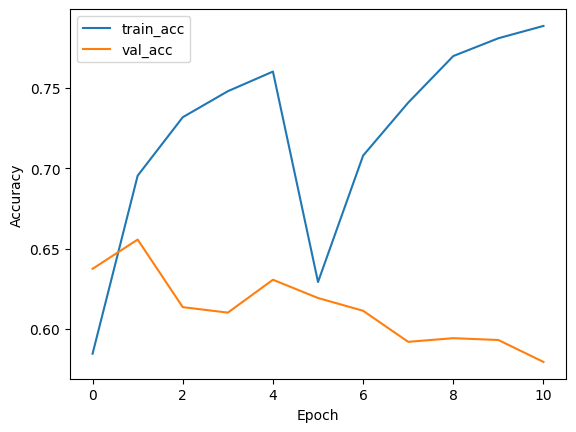

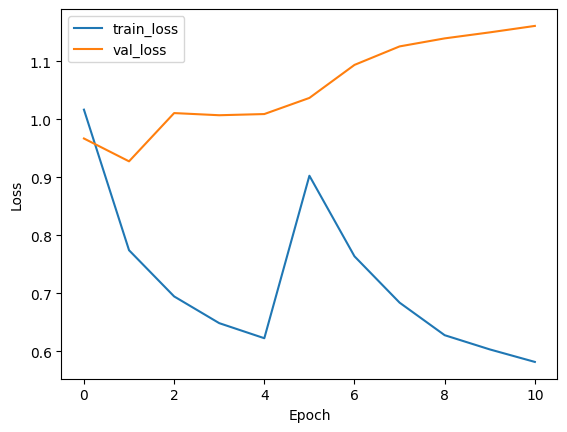

In [ ]:
# 10) Plot Training Curves (Accuracy/Loss)
def plot_curves(h1, h2):
    acc = h1.history["accuracy"] + h2.history["accuracy"]
    val_acc = h1.history["val_accuracy"] + h2.history["val_accuracy"]
    loss = h1.history["loss"] + h2.history["loss"]
    val_loss = h1.history["val_loss"] + h2.history["val_loss"]

    plt.figure()
    plt.plot(acc, label="train_acc")
    plt.plot(val_acc, label="val_acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(loss, label="train_loss")
    plt.plot(val_loss, label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

plot_curves(h1, h2)

In [ ]:
# 11) Evaluate on Test Set
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"\nTest Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}")


Test Accuracy: 0.6193 | Test Loss: 1.0371


In [ ]:
# 12) Predictions
y_true = np.concatenate([y.numpy() for _, y in test_ds], axis=0)
y_prob = model.predict(test_ds, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

In [ ]:
# 13) Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))


Classification Report:
                 precision    recall  f1-score   support

    Anthracnose     0.7391    0.4636    0.5698       220
        Healthy     0.5373    0.9818    0.6945       220
           Scab     0.5082    0.2818    0.3626       220
Styler end root     0.7569    0.7500    0.7534       220

       accuracy                         0.6193       880
      macro avg     0.6354    0.6193    0.5951       880
   weighted avg     0.6354    0.6193    0.5951       880



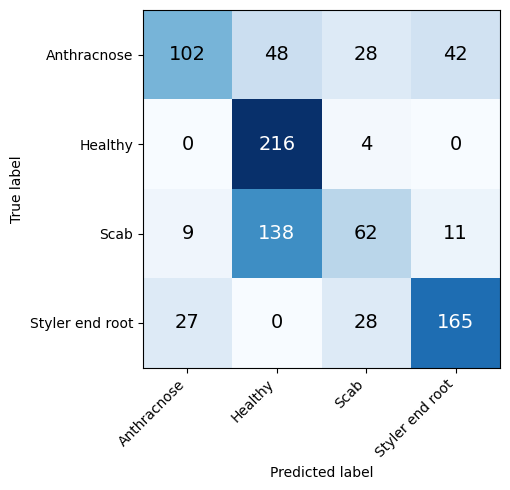

In [ ]:
# 14) Confusion Matrix (blue style like your sample, NO colorbar)
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(7, 5))
ax.imshow(cm, cmap=plt.cm.Blues)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)
thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black", fontsize=14)
ax.grid(False)
plt.tight_layout()
plt.show()

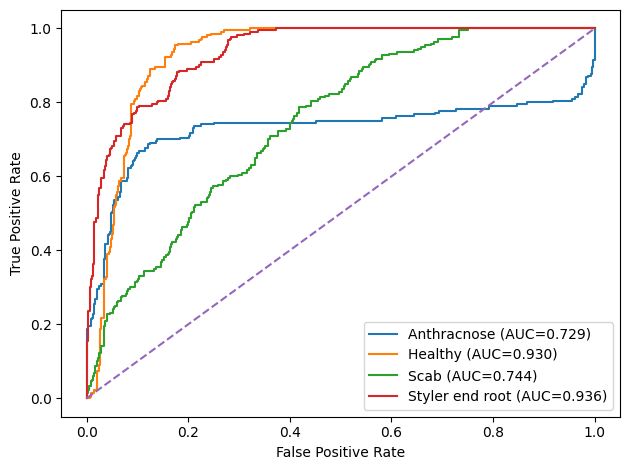

In [ ]:
# 15) ROC Curve (One-vs-Rest)
y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))
plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC={roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# 17) Save Model
import os
os.makedirs("/content/drive/MyDrive/Capstone Models", exist_ok=True)

model.save("/content/drive/MyDrive/Capstone Models/EfficientNetB2_fruit.keras")
print("Model saved successfully.")

Model saved successfully.
